# 05: Anomaly Detection

A different question from `04`'s clustering: KMeans assigns every locality-year to some group, even ones that don't resemble their neighbors. This notebook asks directly which locality-years have a vote-shape pattern unlike almost everything else in the data, independent of cluster membership.

Motivated by `04`'s PCA scatter plot, which had a handful of points stretched far from the main cloud (one past PC2 = 40) -- these turned out to be Manila and Quezon City Councilor races with 100+ candidates for a handful of seats. Measuring anomaly properly across every feature (below) shows this isn't actually the most extreme pattern, but it's what prompted the question.

Same feature set as `04` (`build_core_feature_matrix`: Mayor/Vice Mayor/Councilor top-vote-getter share, margin, log effective-number-of-candidates, standardized), so anomalies here are unusual on the same terms `04`'s clusters were built from.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path("..") / "src"))
from common import build_core_feature_matrix

%matplotlib inline
pd.set_option("display.max_columns", 40)
print("pandas:", pd.__version__)

pandas: 3.0.2


In [2]:
CONFIG = {
    "processed_dir": "../data/processed",
    "random_state": 42,
    "n_estimators": 300,
}

processed_dir = Path(CONFIG["processed_dir"])
print("Config set.")

Config set.


## Load and build the same feature matrix as `04`

In [3]:
locality_features = pd.read_parquet(processed_dir / "locality_features.parquet")
df, X, feature_cols = build_core_feature_matrix(locality_features)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"{len(df):,} complete-case rows, {len(feature_cols)} features:", feature_cols)

8,967 complete-case rows, 9 features: ['MAYOR_top1_share', 'MAYOR_margin', 'MAYOR_enc', 'VICE MAYOR_top1_share', 'VICE MAYOR_margin', 'VICE MAYOR_enc', 'COUNCILOR_top1_share', 'COUNCILOR_margin', 'COUNCILOR_enc']


## Isolation Forest

Isolation Forest scores a point by how few random splits it takes to isolate it from the rest of the data -- outliers separate in few splits, typical points take many. Chosen over a distance-from-centroid rule because it doesn't assume "normal" data forms one blob or a fixed number of them (`04` found two clusters, and outliers can sit near either).

scikit-learn's default `contamination="auto"` flags 28.3% of all locality-years -- too loose to call anomalies. The score distribution has no sharp natural gap, so `contamination` is set explicitly to 2%, a standard conservative convention rather than a threshold read off the data.

Flagged 180 of 8,967 rows (2.0%).


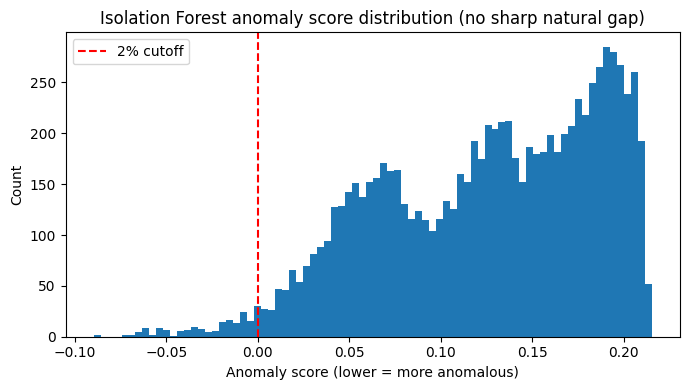

In [4]:
iso_forest = IsolationForest(n_estimators=CONFIG["n_estimators"],
                              random_state=CONFIG["random_state"], contamination=0.02)
iso_forest.fit(X_scaled)

df["anomaly_score"] = iso_forest.decision_function(X_scaled)  # lower = more anomalous
df["is_outlier"] = iso_forest.predict(X_scaled) == -1

print(f"Flagged {df['is_outlier'].sum():,} of {len(df):,} rows ({df['is_outlier'].mean():.1%}).")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df["anomaly_score"], bins=80)
ax.axvline(df.loc[df["is_outlier"], "anomaly_score"].max(), color="red", linestyle="--",
           label="2% cutoff")
ax.set_xlabel("Anomaly score (lower = more anomalous)")
ax.set_ylabel("Count")
ax.set_title("Isolation Forest anomaly score distribution (no sharp natural gap)")
ax.legend()
plt.tight_layout()
plt.show()

## Looking at the flagged outliers directly

Top 15 by anomaly score, with the raw (untransformed) features explaining why each one was flagged.

In [5]:
outliers = df[df["is_outlier"]].sort_values("anomaly_score")
display_cols = ["year", "province", "city", "anomaly_score"] + feature_cols
print(f"{len(outliers)} outliers. Ten most anomalous:")
display(outliers[display_cols].head(10))

180 outliers. Ten most anomalous:


,year,province,city,anomaly_score,MAYOR_top1_share,MAYOR_margin,MAYOR_enc,VICE MAYOR_top1_share,VICE MAYOR_margin,VICE MAYOR_enc,COUNCILOR_top1_share,COUNCILOR_margin,COUNCILOR_enc
5470,2019,SORSOGON,CASTILLA,-0.089793,0.506230,0.012460,1.999690,1.000000,1.000000,1.000000,0.175319,0.039881,7.738974
854,2010,SARANGANI,MAASIM,-0.086557,0.275200,0.000776,4.479864,0.266568,0.053747,5.614466,0.044989,0.002281,39.669588
356,2010,DAVAO DEL SUR,JOSE ABAD SANTOS TRINIDAD,-0.072901,0.271393,0.057179,4.638635,0.257353,0.036117,5.055857,0.056641,0.007391,34.550037
3913,2016,SULU,TALIPAO,-0.071119,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.475260,0.394810,3.769008
8182,2025,LANAO DEL SUR,TAGOLOAN,-0.068916,0.989491,0.982993,1.021293,0.955363,0.931541,1.094665,0.169319,0.048316,8.045305
8253,2025,MAGUINDANAO DEL SUR,GEN S K PENDATUN,-0.067276,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.318807,0.204147,5.935996
7370,2025,AGUSAN DEL SUR,BAYUGAN,-0.066380,0.912371,0.824741,1.190336,0.846351,0.692703,1.351500,0.183527,0.089745,9.598520
3495,2016,NEGROS OCCIDENTAL,PULUPANDAN,-0.065216,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.300412,0.146802,5.954959
796,2010,QUEZON,PATNANUNGAN,-0.065059,0.398446,0.182266,3.643061,0.264954,0.010544,4.348769,0.046008,0.000155,37.291652
8252,2025,MAGUINDANAO DEL SUR,DATU UNSAY,-0.064271,0.997492,0.994984,1.005028,0.994122,0.988245,1.011824,0.203862,0.084529,8.007964


## Sanity check: do the outliers make sense?

The top 10 show two recurring shapes:

- **A near-tied Mayor race alongside a highly fragmented Councilor race** -- Maasim, Sarangani, 2010 (Mayor margin 0.08 points, Councilor effective-candidate count 39.7); Jose Abad Santos-Trinidad, Davao del Sur, 2010; Patnanungan, Quezon, 2010; Tanjay, Negros Oriental, 2016.
- **Mayor and Vice Mayor both completely uncontested in the same election** (margin and effective-candidate count both at their theoretical extremes -- 1.0 and 1.0 -- for both offices): Talipao and Luuk (Sulu, 2016); Gen. S.K. Pendatun and Datu Unsay (Maguindanao, 2025); Amai Manabilang and Calanogas (Lanao del Sur, 2016/2022); Akbar (Basilan, 2025); Languyan (Tawi-Tawi, 2025).

About a third of the 180 flagged rows fit one of these two shapes cleanly; the province breakdown below shows the second pattern isn't spread evenly.

In [6]:
print("Outliers by province (top 10):")
display(outliers["province"].value_counts().head(10).to_frame("n_outlier_years"))

top1 = outliers.iloc[0]
print(f"\nMost anomalous row: {top1['city']}, {top1['province']}, {int(top1['year'])}")
display(outliers.iloc[[0]][["MAYOR_margin", "MAYOR_enc", "VICE MAYOR_margin", "COUNCILOR_enc"]])

uncontested_sweep = (outliers["MAYOR_margin"] > 0.99) & (outliers["VICE MAYOR_margin"] > 0.99)
tight_mayor_fragmented_council = (outliers["MAYOR_margin"] < 0.1) & (outliers["COUNCILOR_enc"] > 20)
print(f"\nOf {len(outliers)} flagged rows: {uncontested_sweep.sum()} are a full Mayor+Vice Mayor "
      f"uncontested sweep, {tight_mayor_fragmented_council.sum()} are a near-tied Mayor race with "
      f"a fragmented Councilor race, {len(outliers) - uncontested_sweep.sum() - tight_mayor_fragmented_council.sum()} "
      f"fit neither pattern cleanly -- a real mix, not one single story.")

manila = df[df["city"] == "MANILA"].sort_values("anomaly_score").iloc[0]
manila_rank = int(df["anomaly_score"].rank()[manila.name])
print(f"\nFor reference, the large-city extreme-fragmentation case visible in 04's PCA plot "
      f"(Manila, {int(manila['year'])}, {int(manila['COUNCILOR_n_candidates'])} Councilor candidates) "
      f"ranks {manila_rank} of {len(df)} by anomaly score -- real and flagged, but not the top-ranked "
      f"pattern once every feature is weighed together instead of two PCA axes.")

Outliers by province (top 10):


,n_outlier_years
province,
MAGUINDANAO,22
SULU,19
LANAO DEL SUR,13
PALAWAN,7
BENGUET,6
DAVAO DEL SUR,5
NCR SECOND DISTRICT,5
MAGUINDANAO DEL SUR,4
NEGROS OCCIDENTAL,4



Most anomalous row: CASTILLA, SORSOGON, 2019


,MAYOR_margin,MAYOR_enc,VICE MAYOR_margin,COUNCILOR_enc
5470,0.01246,1.99969,1.0,7.738974



Of 180 flagged rows: 34 are a full Mayor+Vice Mayor uncontested sweep, 29 are a near-tied Mayor race with a fragmented Councilor race, 117 fit neither pattern cleanly -- a real mix, not one single story.

For reference, the large-city extreme-fragmentation case visible in 04's PCA plot (Manila, 2016, 149 Councilor candidates) ranks 111 of 8967 by anomaly score -- real and flagged, but not the top-ranked pattern once every feature is weighed together instead of two PCA axes.


## Where the outliers sit relative to `04`'s clusters

Same PCA projection style as `04` (refit here, since this notebook doesn't load `04`'s saved model). Outliers aren't confined to one cluster region -- they're unusual relative to the whole dataset, in either cluster's neighborhood.

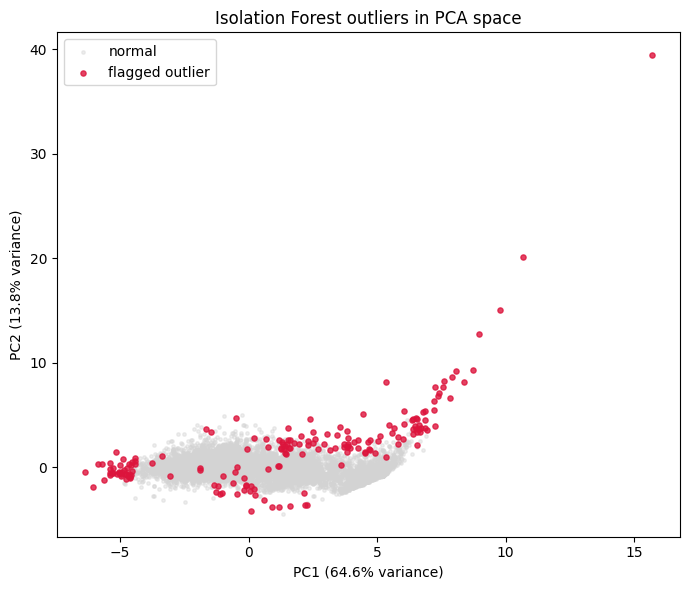

In [7]:
pca = PCA(n_components=2, random_state=CONFIG["random_state"])
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca[~df["is_outlier"], 0], X_pca[~df["is_outlier"], 1],
           s=6, alpha=0.4, color="lightgray", label="normal")
ax.scatter(X_pca[df["is_outlier"], 0], X_pca[df["is_outlier"], 1],
           s=14, alpha=0.8, color="crimson", label="flagged outlier")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("Isolation Forest outliers in PCA space")
ax.legend()
plt.tight_layout()
plt.show()

## Save

In [8]:
anomaly_output = df[["year", "province", "city", "anomaly_score", "is_outlier"] + feature_cols].copy()
anomaly_output.to_parquet(processed_dir / "locality_anomalies.parquet", index=False)
print("Saved locality_anomalies.parquet:", anomaly_output.shape)

Saved locality_anomalies.parquet: (8967, 14)


## Summary

Isolation Forest on `04`'s 9-feature core matrix flags 180 locality-years (2%) with a vote-shape pattern unlike the rest of the data, concentrated in a small number of provinces (Maguindanao, Sulu, and Lanao del Sur account for 30% of them). The top of the list mixes two shapes -- a near-tied Mayor race paired with a fragmented Councilor race, and a Mayor+Vice Mayor pair both completely uncontested -- confirming the extreme points in `04`'s PCA plot were a real signal. The large-city fragmentation case (Manila, Quezon City) that motivated this notebook is real and flagged, but not the top-ranked pattern once every feature is weighed together instead of two PCA axes.

**"Anomalous" here means statistically unusual relative to this dataset's vote-shape features, not suspicious** -- a large city having more Councilor candidates than a small municipality is expected, not a red flag.

**Out of scope here:** anything implying electoral fraud (this is a shape comparison, not a fraud-detection model), and tracking an outlier locality's anomaly score across election years (see `08`).